# NB02: AMR Conservation Patterns — Deep Dive

**Goal**: Test H1 — are AMR genes enriched in the accessory genome? Break down conservation by AMR gene family, mechanism, and species. Compare per-species AMR conservation to that species' overall pangenome structure.

**Depends on**: NB01 outputs (`data/amr_census.csv`, `data/amr_species_summary.csv`)

**Outputs**:
- `../data/amr_conservation_by_gene.csv` — per-AMR-gene conservation stats
- `../data/amr_conservation_by_species.csv` — per-species AMR vs baseline conservation
- `../figures/amr_conservation_*.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 13, 'savefig.bbox': 'tight', 'savefig.dpi': 150,
})

# Load NB01 outputs
amr = pd.read_csv(DATA_DIR / 'amr_census.csv')
species = pd.read_csv(DATA_DIR / 'amr_species_summary.csv')
print(f"Loaded {len(amr):,} AMR clusters across {amr['gtdb_species_clade_id'].nunique():,} species")

Loaded 83,008 AMR clusters across 14,723 species


## 1. Overall Conservation Test

Compare AMR conservation class distribution to the pangenome-wide baseline using chi-squared and odds ratios. The key question: are AMR genes disproportionately accessory?

In [2]:
# Derive conservation_class if not already present
if 'conservation_class' not in amr.columns:
    amr['conservation_class'] = np.where(
        amr['is_core'], 'Core',
        np.where(amr['is_singleton'], 'Singleton', 'Auxiliary')
    )

# AMR conservation distribution
amr_counts = amr['conservation_class'].value_counts()
amr_total = len(amr)

# Pangenome baseline (from schema docs, mutually exclusive)
baseline = {
    'Core': 62_062_686,
    'Auxiliary': 70_468_815 - 50_203_195,  # aux non-singleton
    'Singleton': 50_203_195
}
baseline_total = sum(baseline.values())

print("=== H1 Test: AMR Conservation vs Pangenome Baseline ===\n")
print(f"{'Class':<15} {'AMR Count':>10} {'AMR %':>8} {'Baseline %':>12} {'Enrichment':>12}")
print("-" * 60)
for cls in ['Core', 'Auxiliary', 'Singleton']:
    amr_n = amr_counts.get(cls, 0)
    amr_pct = amr_n / amr_total * 100
    base_pct = baseline[cls] / baseline_total * 100
    enrichment = amr_pct / base_pct
    print(f"{cls:<15} {amr_n:>10,} {amr_pct:>7.1f}% {base_pct:>11.1f}% {enrichment:>11.2f}x")

# Chi-squared test
observed = np.array([amr_counts.get(c, 0) for c in ['Core', 'Auxiliary', 'Singleton']])
expected_frac = np.array([baseline[c] / baseline_total for c in ['Core', 'Auxiliary', 'Singleton']])
expected = expected_frac * amr_total
chi2, p_chi = stats.chisquare(observed, expected)
print(f"\nChi-squared: {chi2:.1f}, p = {p_chi:.2e}")

# Odds ratio: core vs non-core
amr_core = amr_counts.get('Core', 0)
amr_noncore = amr_total - amr_core
base_core = baseline['Core']
base_noncore = baseline_total - base_core

# 2x2 contingency table: AMR vs non-AMR x Core vs Non-core
table = np.array([[amr_core, amr_noncore],
                   [base_core, base_noncore]])
oddsratio = (amr_core * base_noncore) / (amr_noncore * base_core)
print(f"\nOdds ratio (core in AMR vs baseline): {oddsratio:.3f}")
print(f"  OR < 1 means AMR genes are DEPLETED in core (enriched in accessory)")
print(f"  OR > 1 means AMR genes are ENRICHED in core")

=== H1 Test: AMR Conservation vs Pangenome Baseline ===

Class            AMR Count    AMR %   Baseline %   Enrichment
------------------------------------------------------------
Core                25,172    30.3%        46.8%        0.65x
Auxiliary           27,899    33.6%        15.3%        2.20x
Singleton           29,937    36.1%        37.9%        0.95x

Chi-squared: 23117.2, p = 0.00e+00

Odds ratio (core in AMR vs baseline): 0.494
  OR < 1 means AMR genes are DEPLETED in core (enriched in accessory)
  OR > 1 means AMR genes are ENRICHED in core


## 2. Per-Species Conservation: AMR vs Species Baseline

For each species, compare: what fraction of its AMR clusters are core vs what fraction of ALL its clusters are core? This controls for species-level variation in pangenome structure.

In [3]:
# Per-species: AMR core fraction vs species-wide core fraction
species_cons = species.copy()
species_cons['amr_core_frac'] = species_cons['n_core_amr'] / species_cons['n_amr']
species_cons['species_core_frac'] = species_cons['no_core_gene_clusters'] / species_cons['no_gene_clusters']
species_cons['core_enrichment'] = species_cons['amr_core_frac'] - species_cons['species_core_frac']

# Filter to species with enough AMR genes for meaningful comparison
min_amr = 5
sp_enough = species_cons[species_cons['n_amr'] >= min_amr].copy()
print(f"Species with >= {min_amr} AMR clusters: {len(sp_enough):,}")
print(f"\n=== Per-Species Core Fraction: AMR vs All Genes ===")
print(f"Mean AMR core fraction: {sp_enough['amr_core_frac'].mean():.3f}")
print(f"Mean species core fraction: {sp_enough['species_core_frac'].mean():.3f}")
print(f"Mean difference (AMR - baseline): {sp_enough['core_enrichment'].mean():.3f}")

# Paired test: is AMR core fraction systematically different from species baseline?
t_stat, p_paired = stats.ttest_rel(sp_enough['amr_core_frac'], sp_enough['species_core_frac'])
print(f"\nPaired t-test: t={t_stat:.2f}, p={p_paired:.2e}")

wilcox_stat, p_wilcox = stats.wilcoxon(sp_enough['core_enrichment'])
print(f"Wilcoxon signed-rank: W={wilcox_stat:.0f}, p={p_wilcox:.2e}")

# How many species have AMR genes more core vs less core than average?
n_more_core = (sp_enough['core_enrichment'] > 0).sum()
n_less_core = (sp_enough['core_enrichment'] < 0).sum()
print(f"\nSpecies where AMR is more core than average: {n_more_core} ({n_more_core/len(sp_enough)*100:.1f}%)")
print(f"Species where AMR is less core than average: {n_less_core} ({n_less_core/len(sp_enough)*100:.1f}%)")

Species with >= 5 AMR clusters: 4,252

=== Per-Species Core Fraction: AMR vs All Genes ===
Mean AMR core fraction: 0.389
Mean species core fraction: 0.491
Mean difference (AMR - baseline): -0.102

Paired t-test: t=-26.62, p=1.54e-144
Wilcoxon signed-rank: W=2569438, p=1.10e-130

Species where AMR is more core than average: 1540 (36.2%)
Species where AMR is less core than average: 2709 (63.7%)


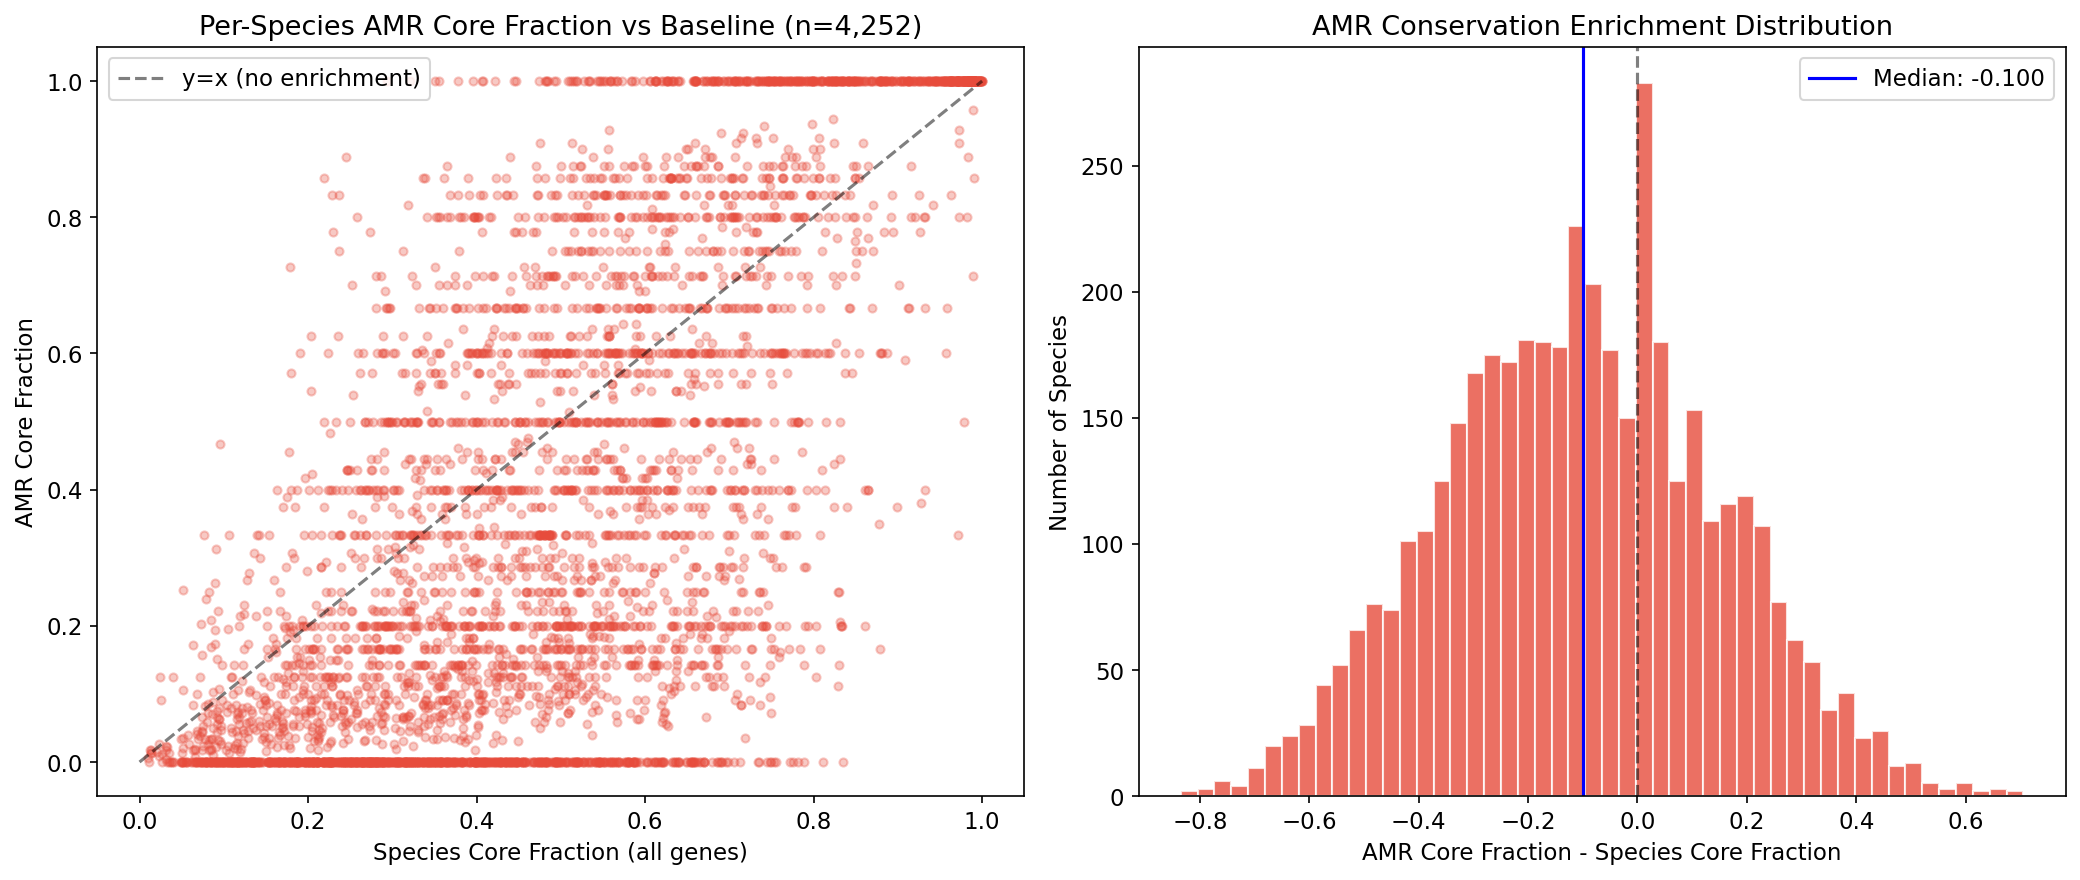

In [4]:
# Scatter: AMR core fraction vs species core fraction
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Scatter with identity line
ax = axes[0]
ax.scatter(sp_enough['species_core_frac'], sp_enough['amr_core_frac'],
           alpha=0.3, s=15, c='#e74c3c')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='y=x (no enrichment)')
ax.set_xlabel('Species Core Fraction (all genes)')
ax.set_ylabel('AMR Core Fraction')
ax.set_title(f'Per-Species AMR Core Fraction vs Baseline (n={len(sp_enough):,})')
ax.legend()

# Panel 2: Distribution of enrichment (AMR core - species core)
ax = axes[1]
ax.hist(sp_enough['core_enrichment'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.axvline(sp_enough['core_enrichment'].median(), color='blue', linestyle='-',
           label=f'Median: {sp_enough["core_enrichment"].median():.3f}')
ax.set_xlabel('AMR Core Fraction - Species Core Fraction')
ax.set_ylabel('Number of Species')
ax.set_title('AMR Conservation Enrichment Distribution')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'amr_conservation_per_species.png')
plt.show()

## 3. Conservation by AMR Gene Family

Which specific AMR genes are consistently core vs consistently accessory?

In [5]:
# Per-AMR-gene conservation stats
gene_cons = amr.groupby('amr_gene').agg(
    total=('gene_cluster_id', 'count'),
    n_core=('conservation_class', lambda x: (x == 'Core').sum()),
    n_aux=('conservation_class', lambda x: (x == 'Auxiliary').sum()),
    n_sing=('conservation_class', lambda x: (x == 'Singleton').sum()),
    n_species=('gtdb_species_clade_id', 'nunique'),
    n_phyla=('phylum', 'nunique'),
    mean_identity=('identity', 'mean')
).reset_index()

gene_cons['pct_core'] = (gene_cons['n_core'] / gene_cons['total'] * 100).round(1)
gene_cons = gene_cons.sort_values('total', ascending=False)

# Save
gene_cons.to_csv(DATA_DIR / 'amr_conservation_by_gene.csv', index=False)

# Show most common genes with conservation info
print("=== Top 30 AMR Genes by Frequency ===")
print(gene_cons[['amr_gene', 'total', 'n_species', 'n_phyla', 'pct_core', 'mean_identity']]
      .head(30).to_string(index=False))

# Most-core AMR genes (min 10 occurrences)
print(f"\n=== Most Core AMR Genes (min 10 occurrences) ===")
core_genes = gene_cons[gene_cons['total'] >= 10].nlargest(15, 'pct_core')
print(core_genes[['amr_gene', 'total', 'n_species', 'pct_core']].to_string(index=False))

# Most-accessory AMR genes (min 10 occurrences)
print(f"\n=== Most Accessory AMR Genes (min 10 occurrences) ===")
acc_genes = gene_cons[gene_cons['total'] >= 10].nsmallest(15, 'pct_core')
print(acc_genes[['amr_gene', 'total', 'n_species', 'pct_core']].to_string(index=False))

=== Top 30 AMR Genes by Frequency ===
amr_gene  total  n_species  n_phyla  pct_core  mean_identity
     bla   6115       4660       35      67.7       0.946768
    merA   4506       2886       55      15.8       0.957296
    arsD   2611       2087       51      34.4       0.954107
    merP   2222       1200       14       8.5       0.955716
    vanR   1929       1534       13      51.7       0.914681
  blaOXA   1811       1490       27      60.6       0.984354
     arr   1607       1443       21      59.9       0.996648
     cml   1302        924        3      68.6       0.968625
    ampC   1273       1197        7      78.6       0.971817
   arsN1   1213        934       32      41.4       0.952106
   arsN2   1173        903       34      37.6       0.971030
 aac(6')   1112       1005       29      51.7       0.983845
    merC    950        607       10       5.5       0.987090
     vat    922        880       26      44.8            NaN
   blaR1    922        651       10      29.8  

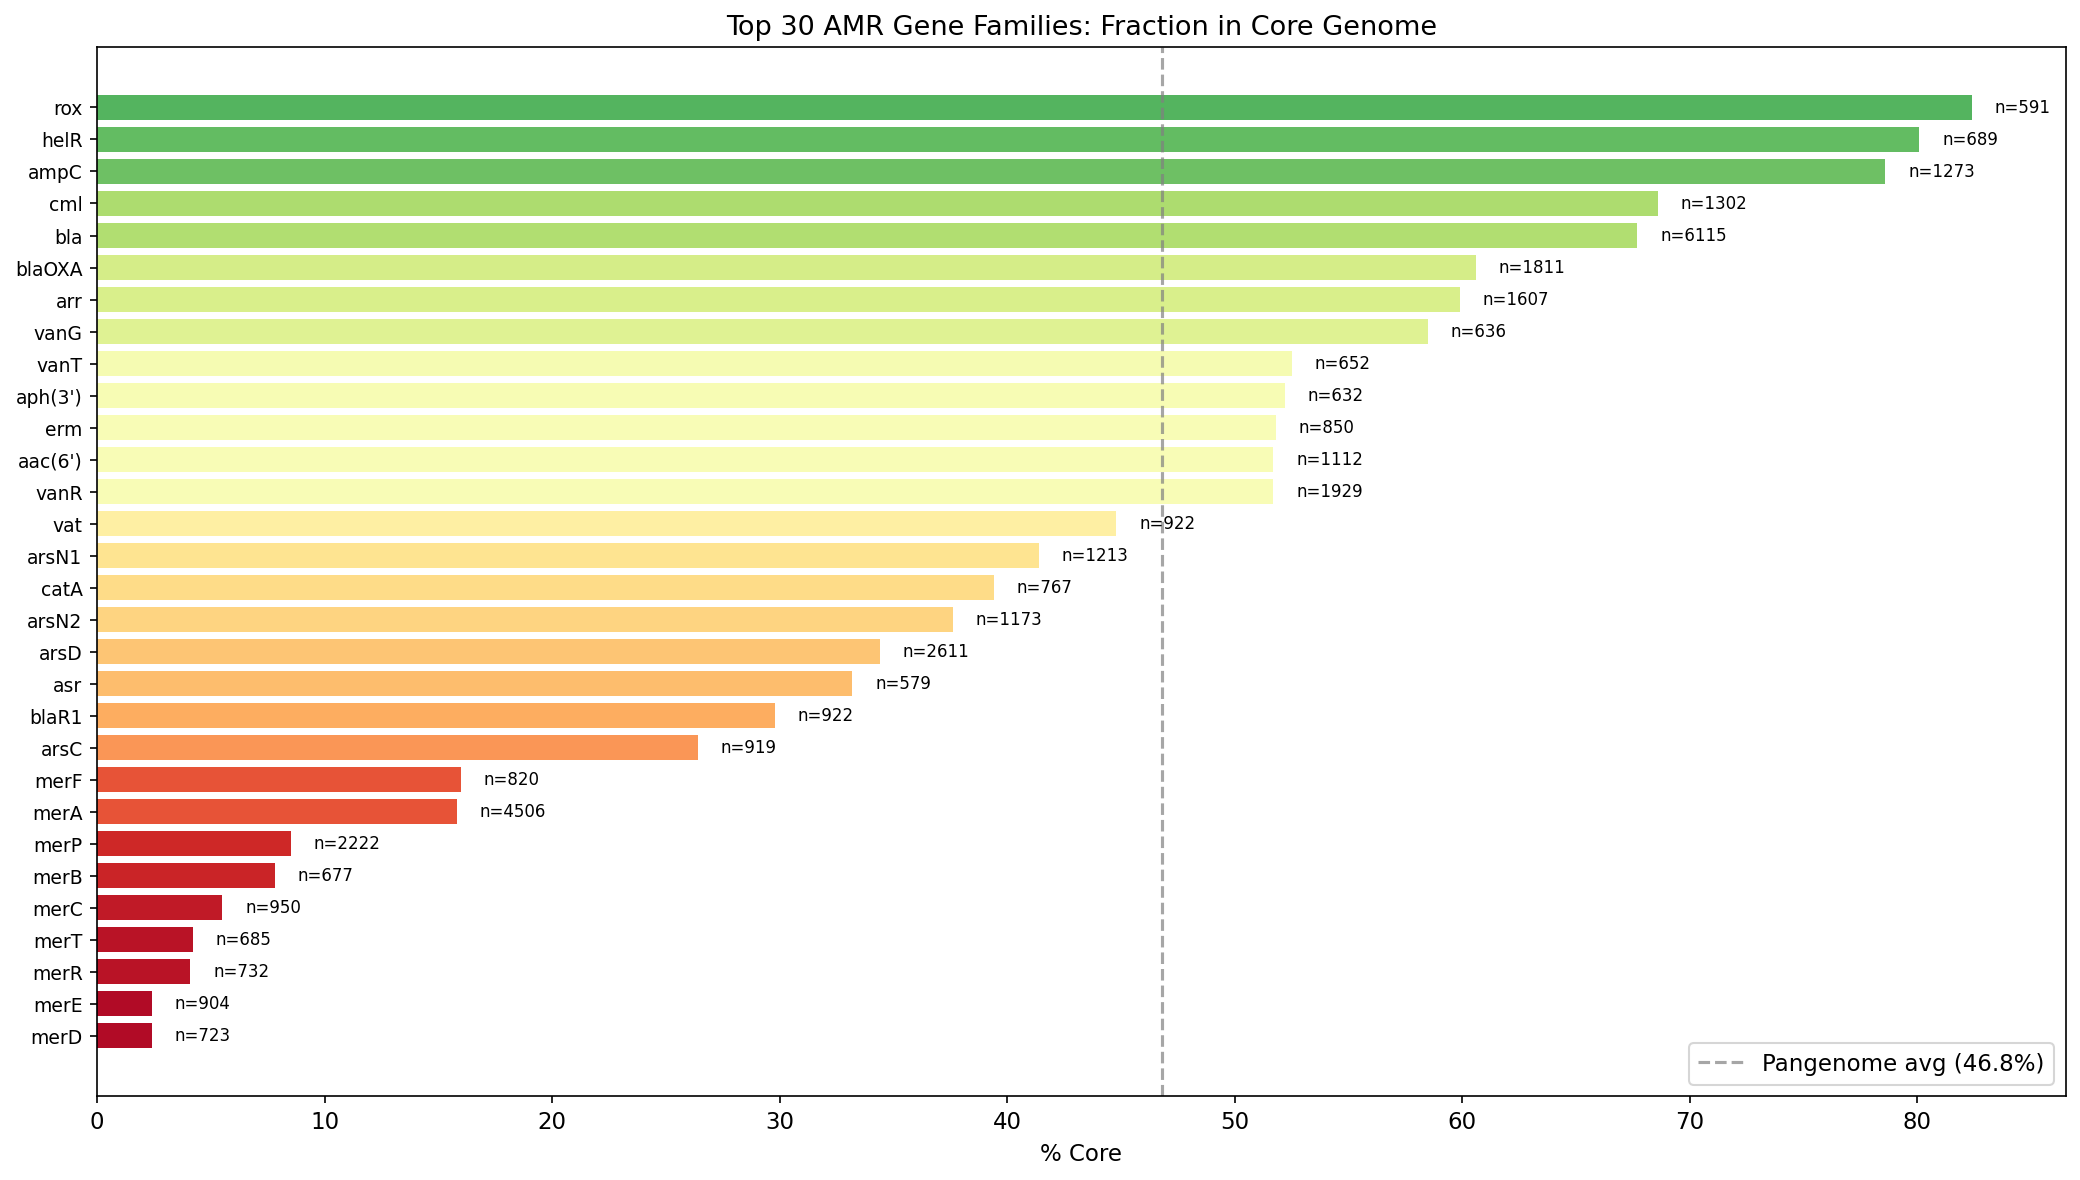

In [6]:
# Visualization: AMR gene families ranked by % core
fig, ax = plt.subplots(figsize=(14, 8))

# Top 30 genes by frequency, colored by % core
top30 = gene_cons.head(30).sort_values('pct_core')
colors = plt.cm.RdYlGn(top30['pct_core'] / 100)

bars = ax.barh(range(len(top30)), top30['pct_core'], color=colors)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['amr_gene'], fontsize=9)
ax.set_xlabel('% Core')
ax.set_title('Top 30 AMR Gene Families: Fraction in Core Genome')
ax.axvline(46.8, color='gray', linestyle='--', alpha=0.7, label='Pangenome avg (46.8%)')
ax.legend()

# Add count labels
for i, (_, row) in enumerate(top30.iterrows()):
    ax.text(row['pct_core'] + 1, i, f'n={int(row["total"])}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'amr_gene_families_core_fraction.png')
plt.show()

## 4. Conservation by Mechanism Class

Do different resistance mechanisms (efflux, enzymatic, target modification) show different conservation patterns?

In [7]:
# Conservation by mechanism (if mechanism column exists from NB01)
if 'mechanism' not in amr.columns:
    # Re-derive mechanism classification
    def classify_mechanism(product):
        if pd.isna(product):
            return 'Unknown'
        p = product.lower()
        if any(k in p for k in ['efflux', 'pump', 'transporter', 'exporter', 'permease']):
            return 'Efflux'
        if any(k in p for k in ['beta-lactamase', 'lactamase', 'carbapenemase']):
            return 'Beta-lactamase'
        if any(k in p for k in ['acetyltransferase', 'phosphotransferase', 'nucleotidyltransferase',
                                 'aminoglycoside-modifying', 'chloramphenicol acetyltransferase',
                                 'inactivat', 'hydrolase']):
            return 'Enzymatic inactivation'
        if any(k in p for k in ['methyltransferase', 'ribosomal protection', '16s rrna methyltransferase',
                                 'target protect', 'erm(', 'cfr(']):
            return 'Target modification'
        if any(k in p for k in ['penicillin-binding', 'pbp', 'vancomycin resistance', 'van', 'lipid a', 'mcr-']):
            return 'Cell wall modification'
        if any(k in p for k in ['regulator', 'repressor', 'activator', 'transcription']):
            return 'Regulatory'
        return 'Other/Unclassified'
    amr['mechanism'] = amr['amr_product'].apply(classify_mechanism)

# Chi-squared test for each mechanism vs baseline
print("=== Conservation by Mechanism: Chi-squared vs Baseline ===\n")
baseline_core_frac = baseline['Core'] / baseline_total

for mech in amr['mechanism'].value_counts().head(8).index:
    subset = amr[amr['mechanism'] == mech]
    n = len(subset)
    n_core = (subset['conservation_class'] == 'Core').sum()
    pct_core = n_core / n * 100
    
    # Binomial test: is the core fraction significantly different from baseline?
    p_binom = stats.binomtest(n_core, n, baseline_core_frac).pvalue
    direction = "MORE core" if pct_core > baseline_core_frac * 100 else "LESS core"
    sig = "***" if p_binom < 0.001 else "**" if p_binom < 0.01 else "*" if p_binom < 0.05 else "ns"
    
    print(f"  {mech:<25} n={n:>6,}  core={pct_core:>5.1f}%  vs baseline {baseline_core_frac*100:.1f}%  "
          f"{direction}  p={p_binom:.2e} {sig}")

=== Conservation by Mechanism: Chi-squared vs Baseline ===

  Other/Unclassified        n=18,448  core= 24.0%  vs baseline 46.8%  LESS core  p=0.00e+00 ***
  Enzymatic inactivation    n=15,755  core= 28.2%  vs baseline 46.8%  LESS core  p=0.00e+00 ***
  Efflux                    n=14,338  core= 30.9%  vs baseline 46.8%  LESS core  p=0.00e+00 ***
  Beta-lactamase            n=12,824  core= 54.9%  vs baseline 46.8%  MORE core  p=7.70e-74 ***
  Target modification       n= 6,955  core= 19.6%  vs baseline 46.8%  LESS core  p=0.00e+00 ***
  Oxidoreductase            n= 6,852  core= 15.4%  vs baseline 46.8%  LESS core  p=0.00e+00 ***
  Cell wall modification    n= 4,964  core= 45.2%  vs baseline 46.8%  LESS core  p=2.20e-02 *
  Regulatory                n= 2,848  core=  6.5%  vs baseline 46.8%  LESS core  p=0.00e+00 ***


In [8]:
# Save per-species conservation comparison
species_cons.to_csv(DATA_DIR / 'amr_conservation_by_species.csv', index=False)
print(f"Saved {len(species_cons):,} species to data/amr_conservation_by_species.csv")

print("\n=== NB02 Summary ===")
print(f"H1 test: AMR core fraction vs baseline — see chi-squared and OR above")
print(f"Per-species paired test: {len(sp_enough):,} species with >= {min_amr} AMR genes")
print(f"Per-gene conservation: {len(gene_cons):,} distinct AMR gene families characterized")

Saved 14,723 species to data/amr_conservation_by_species.csv

=== NB02 Summary ===
H1 test: AMR core fraction vs baseline — see chi-squared and OR above
Per-species paired test: 4,252 species with >= 5 AMR genes
Per-gene conservation: 1,939 distinct AMR gene families characterized
